# Chapter 8 — Learning Signal and Ignoring Noise

**Grokking Deep Learning — Andrew W. Trask**


Chapter 8 membahas **overfitting, dropout, dan batch gradient descent**. Fokus notebook ini adalah mereproduksi eksperimen dan menampilkan hasilnya dengan visual yang dipilih berdasarkan jenis data/hasilnya.

## Learning Objectives

Setelah menyelesaikan Chapter 8, kita diharapkan dapat:
- menjelaskan perbedaan **memorization** dan **generalization**;
- mengenali gejala **overfitting** dari perbedaan training dan testing performance;
- memahami fungsi **early stopping** sebagai regularization sederhana;
- menjelaskan bagaimana **dropout** mengurangi overfitting;
- memahami ide **ensemble** di balik dropout;
- menjelaskan mengapa **batch gradient descent** membuat proses training lebih cepat dan lebih smooth.

## Chapter Roadmap

**MNIST → Overfitting → Memorization vs Generalization → Early Stopping → Dropout → Ensembling → Batch Gradient Descent**

Visual di notebook ini tidak dipaksakan menjadi satu jenis chart. Hasil yang berupa perubahan terhadap iteration ditampilkan sebagai **line chart**; perbandingan antar-model menggunakan **bar chart**; komposisi dropout menggunakan **stacked bar**; sedangkan struktur data dan contoh digit ditampilkan dengan visual yang sesuai.

## 1. Three-Layer Network on MNIST

Buku kembali menggunakan MNIST untuk menguji three-layer neural network. Training menggunakan **1,000 gambar** pertama, setiap gambar berukuran **28 × 28 = 784 pixels**, hidden layer memiliki **40 nodes**, dan output memiliki **10 labels**.

Network ini sengaja dibuat cukup powerful sehingga kita dapat melihat masalah utama: network mampu mempelajari training data dengan sangat baik, tetapi belum tentu dapat melakukan generalization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter arsitektur yang digunakan pada eksperimen Chapter 8
pixels_per_image = 784
hidden_size = 40
num_labels = 10

parameter_counts = {
    "weights_0_1": pixels_per_image * hidden_size,
    "weights_1_2": hidden_size * num_labels
}
parameter_counts, sum(parameter_counts.values())

({'weights_0_1': 31360, 'weights_1_2': 400}, 31760)

### Interpretasi

Dari shape matrix pada kode, `weights_0_1` berukuran **784 × 40** dan `weights_1_2` berukuran **40 × 10**. Jadi total weight pada konfigurasi awal adalah **31,760**.

Chart berikut digunakan karena outputnya berupa **perbandingan jumlah parameter**, sehingga bar chart lebih tepat daripada diagram node yang sangat padat.

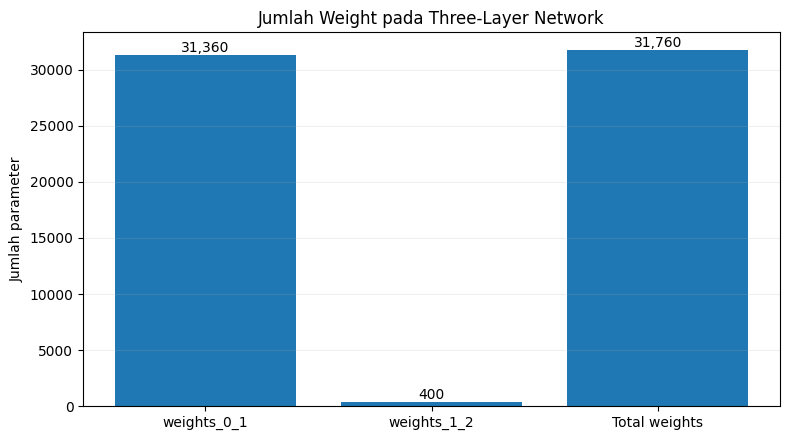

In [ ]:
labels = list(parameter_counts.keys()) + ["Total weights"]
values = list(parameter_counts.values()) + [sum(parameter_counts.values())]

fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(labels, values)
ax.set_title("Jumlah Weight pada Three-Layer Network")
ax.set_ylabel("Jumlah parameter")
ax.grid(axis="y", alpha=0.2)
for b,v in zip(bars,values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Reproducing the Book's MNIST Training Code

Kode berikut mempertahankan struktur eksperimen dari buku: MNIST, 1,000 training images, one-hot labels, ReLU hidden layer, 350 iterations, dan stochastic update per image.

**Catatan eksekusi:** source code menggunakan `keras.datasets.mnist`. Environment pembuatan notebook ini tidak memiliki TensorFlow, sehingga cell reproduksi di bawah disediakan untuk dijalankan langsung di Google Colab setelah environment memiliki Keras/TensorFlow. Hasil numerik yang ditampilkan pada bagian berikut berasal dari output eksperimen yang dilaporkan di buku.

In [ ]:
# SOURCE CODE REPRODUCTION — Chapter 8 (book version)
import sys, numpy as np
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
images, labels = (x_train[0:1000].reshape(1000,28*28) / 255, y_train[0:1000])
one_hot_labels = np.zeros((len(labels),10))
for i,l in enumerate(labels):
    one_hot_labels[i][l] = 1
labels = one_hot_labels
test_images = x_test.reshape(len(x_test),28*28) / 255
test_labels = np.zeros((len(y_test),10))
for i,l in enumerate(y_test):
    test_labels[i][l] = 1

np.random.seed(1)
relu = lambda x:(x>=0) * x
relu2deriv = lambda x: x>=0
alpha, iterations, hidden_size, pixels_per_image, num_labels = (0.005, 350, 40, 784, 10)
weights_0_1 = 0.2*np.random.random((pixels_per_image,hidden_size)) - 0.1
weights_1_2 = 0.2*np.random.random((hidden_size,num_labels)) - 0.1

for j in range(iterations):
    error, correct_cnt = (0.0, 0)
    for i in range(len(images)):
        layer_0 = images[i:i+1]
        layer_1 = relu(np.dot(layer_0,weights_0_1))
        layer_2 = np.dot(layer_1,weights_1_2)
        error += np.sum((labels[i:i+1] - layer_2) ** 2)
        correct_cnt += int(np.argmax(layer_2) == np.argmax(labels[i:i+1]))
        layer_2_delta = (labels[i:i+1] - layer_2)
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
        weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

print("Training complete")

## 3. Melihat Overfitting dari Training vs Testing

Buku menunjukkan bahwa training accuracy terus meningkat, sedangkan test accuracy justru meningkat di awal lalu menurun. Ini adalah pola utama **overfitting**.

Data di bawah adalah checkpoint yang ditampilkan dalam buku.

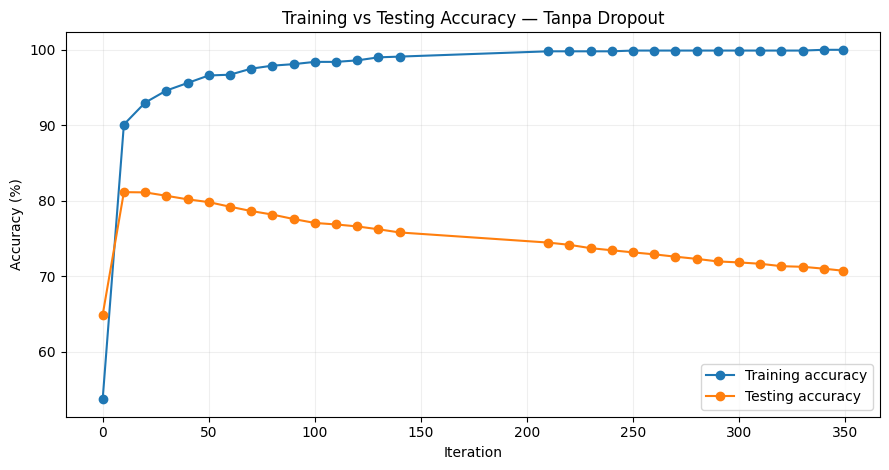

In [ ]:
# Output checkpoints yang dilaporkan buku
iterations_base = np.array([0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,210,220,230,240,250,260,270,280,290,300,310,320,330,340,349])
train_acc_base = np.array([0.537,0.901,0.930,0.946,0.956,0.966,0.967,0.975,0.979,0.981,0.984,0.984,0.986,0.990,0.991,0.998,0.998,0.998,0.998,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,0.999,1.0,1.0])
test_acc_base = np.array([0.6488,0.8114,0.8111,0.8066,0.8019,0.7982,0.7921,0.7864,0.7817,0.7758,0.7706,0.7686,0.7660,0.7622,0.7580,0.7446,0.7416,0.7372,0.7344,0.7316,0.7290,0.7259,0.7230,0.7196,0.7183,0.7165,0.7133,0.7125,0.7100,0.7073])

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(iterations_base, train_acc_base*100, marker="o", label="Training accuracy")
ax.plot(iterations_base, test_acc_base*100, marker="o", label="Testing accuracy")
ax.set_title("Training vs Testing Accuracy — Tanpa Dropout")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Inti hasil

Training accuracy berakhir pada **100%**, sedangkan testing accuracy berakhir sekitar **70.73%**. Buku menjelaskan bahwa test accuracy adalah ukuran yang lebih relevan untuk memperkirakan performa pada data yang belum pernah dilihat network.

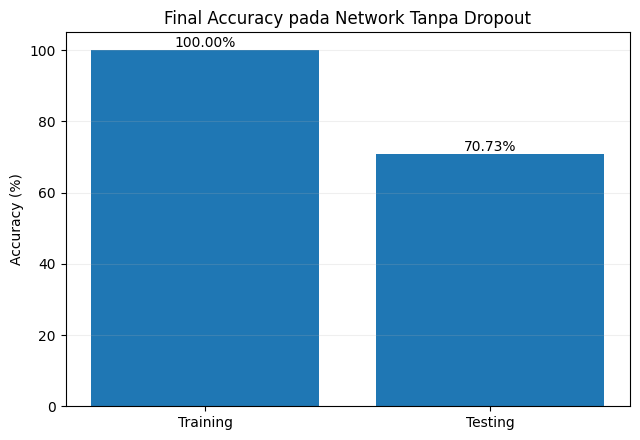

In [ ]:
final_compare = {"Training":100.0, "Testing":70.73}
fig, ax = plt.subplots(figsize=(6.5,4.5))
bars=ax.bar(final_compare.keys(), final_compare.values())
ax.set_ylim(0,105)
ax.set_title("Final Accuracy pada Network Tanpa Dropout")
ax.set_ylabel("Accuracy (%)")
for b,v in zip(bars,final_compare.values()):
    ax.text(b.get_x()+b.get_width()/2,v+1,f"{v:.2f}%",ha="center")
ax.grid(axis="y",alpha=0.2)
plt.tight_layout(); plt.show()

## 4. Memorization vs Generalization

**Memorization** berarti network sangat cocok dengan data training yang sudah dilihat. **Generalization** berarti network tetap mampu bekerja pada data baru.

Pada eksperimen ini, gap antara training dan testing performance menjadi indikator yang mudah dilihat untuk masalah overfitting.

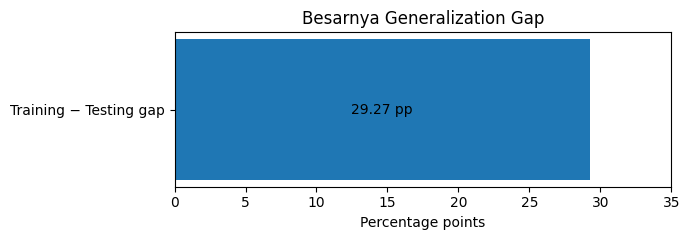

In [ ]:
gap = 100.0 - 70.73
fig, ax = plt.subplots(figsize=(7,2.5))
ax.barh(["Training − Testing gap"],[gap])
ax.set_xlim(0,35)
ax.set_xlabel("Percentage points")
ax.set_title("Besarnya Generalization Gap")
ax.text(gap/2,0,f"{gap:.2f} pp",ha="center",va="center")
plt.tight_layout(); plt.show()

## 5. Early Stopping

Buku memperkenalkan **early stopping** sebagai regularization sederhana: jangan terus melatih network setelah performa pada validation/testing mulai memburuk.

Visual yang paling sesuai di sini adalah menandai **titik terbaik testing accuracy** pada kurva, bukan membuat angka baru.

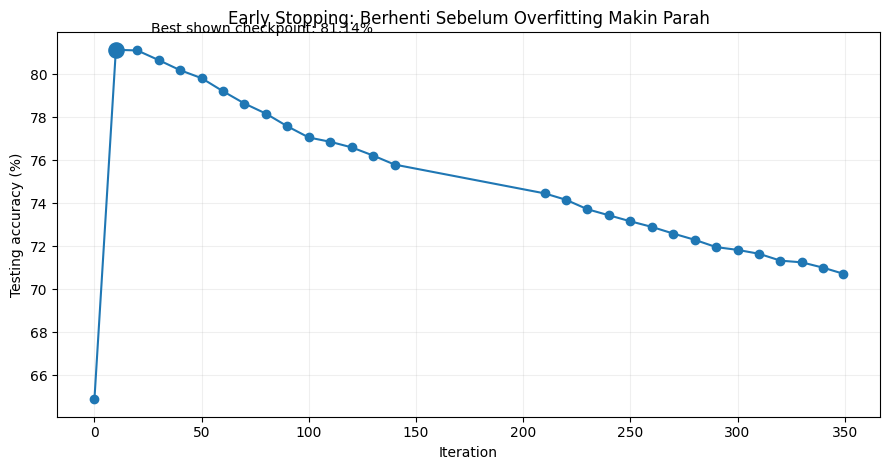

In [ ]:
best_idx = int(np.argmax(test_acc_base))
fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(iterations_base, test_acc_base*100, marker="o")
ax.scatter([iterations_base[best_idx]],[test_acc_base[best_idx]*100],s=120,zorder=5)
ax.annotate(f"Best shown checkpoint: {test_acc_base[best_idx]*100:.2f}%",
            (iterations_base[best_idx],test_acc_base[best_idx]*100),
            xytext=(25,12),textcoords="offset points")
ax.set_title("Early Stopping: Berhenti Sebelum Overfitting Makin Parah")
ax.set_xlabel("Iteration"); ax.set_ylabel("Testing accuracy (%)")
ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 6. Dropout

Buku kemudian memperkenalkan **dropout**. Pada eksperimen ini, 50% hidden nodes dimatikan secara acak selama training menggunakan `dropout_mask` yang berisi 0 dan 1.

Karena 50% node dimatikan, nilai hidden layer yang tetap aktif dikalikan **2** agar skala signal tetap sebanding saat testing.

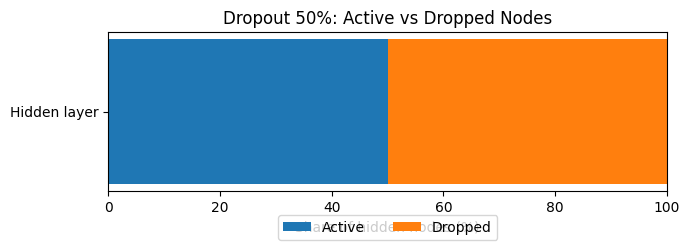

In [ ]:
# Contoh mask 50% secara konseptual sesuai mekanisme buku
active = 50
off = 50
fig, ax = plt.subplots(figsize=(7,2.8))
ax.barh(["Hidden layer"],[active],label="Active")
ax.barh(["Hidden layer"],[off],left=[active],label="Dropped")
ax.set_xlim(0,100)
ax.set_xlabel("Share of hidden nodes (%)")
ax.set_title("Dropout 50%: Active vs Dropped Nodes")
ax.legend(loc="lower center", bbox_to_anchor=(0.5,-0.35), ncol=2)
plt.tight_layout(); plt.show()

### Mengapa dikalikan 2?

Jika hanya 50% node yang aktif, jumlah signal yang masuk ke layer berikutnya dapat turun. Buku mengimbanginya dengan faktor `1 / 0.5 = 2` pada node yang tetap aktif. Ini menjaga skala signal antara training dan testing.

In [ ]:
dropout_rate = 0.50
scale_factor = 1 / (1-dropout_rate)
print(f"Dropout rate: {dropout_rate:.0%}")
print(f"Active proportion: {1-dropout_rate:.0%}")
print(f"Scaling factor: {scale_factor:.1f}x")

Dropout rate: 50%
Active proportion: 50%
Scaling factor: 2.0x


## 7. Dropout Evaluated on MNIST

Buku memberikan output setiap 10 iterations. Berbeda dari baseline, dropout membuat training lebih sulit tetapi testing performance lebih stabil dan overfitting berkurang.

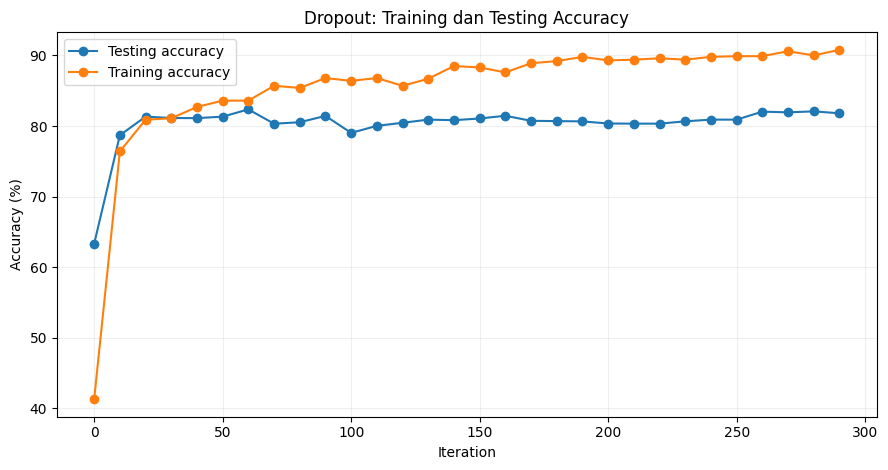

In [ ]:
iterations_do = np.arange(0,300,10)
test_acc_do = np.array([0.6333,0.787,0.8133,0.8114,0.8112,0.8133,0.8236,0.8033,0.8054,0.8144,0.7903,0.8003,0.8046,0.8091,0.8083,0.8107,0.8146,0.8074,0.8070,0.8066,0.8036,0.8034,0.8034,0.8067,0.8091,0.8091,0.8204,0.8194,0.8208,0.8181])
train_acc_do = np.array([0.413,0.764,0.809,0.811,0.827,0.836,0.836,0.857,0.854,0.868,0.864,0.868,0.857,0.867,0.885,0.883,0.876,0.889,0.892,0.898,0.893,0.894,0.896,0.894,0.898,0.899,0.899,0.906,0.900,0.908])

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(iterations_do,test_acc_do*100,marker="o",label="Testing accuracy")
ax.plot(iterations_do,train_acc_do*100,marker="o",label="Training accuracy")
ax.set_title("Dropout: Training dan Testing Accuracy")
ax.set_xlabel("Iteration"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

### Peak dan final performance

Buku menyebutkan testing accuracy dengan dropout mencapai **82.36%** dan berakhir pada **81.81%**, jauh lebih stabil dibanding baseline yang berakhir pada 70.73%.

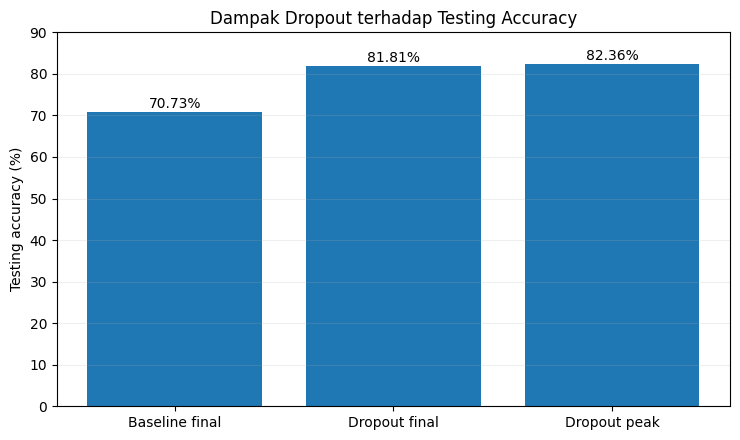

In [ ]:
dropout_compare = {"Baseline final":70.73,"Dropout final":81.81,"Dropout peak":82.36}
fig, ax = plt.subplots(figsize=(7.5,4.5))
bars=ax.bar(dropout_compare.keys(),dropout_compare.values())
ax.set_ylim(0,90); ax.set_ylabel("Testing accuracy (%)")
ax.set_title("Dampak Dropout terhadap Testing Accuracy")
for b,v in zip(bars,dropout_compare.values()): ax.text(b.get_x()+b.get_width()/2,v+1,f"{v:.2f}%",ha="center")
ax.grid(axis="y",alpha=0.2); plt.tight_layout(); plt.show()

## 8. Why Dropout Works: Ensembling

Buku menjelaskan bahwa dua network yang diinisialisasi secara random cenderung melakukan kesalahan yang berbeda. Jika banyak network seperti ini diberi kesempatan untuk “vote”, noise yang berbeda-beda cenderung saling mengurangi, sementara signal yang sama lebih mungkin bertahan.

Bagian ini bersifat konseptual, sehingga tidak dibuat menjadi chart dengan angka yang tidak ada di sumber. Visual berikut hanya menunjukkan ide **many models → voting → shared signal**.

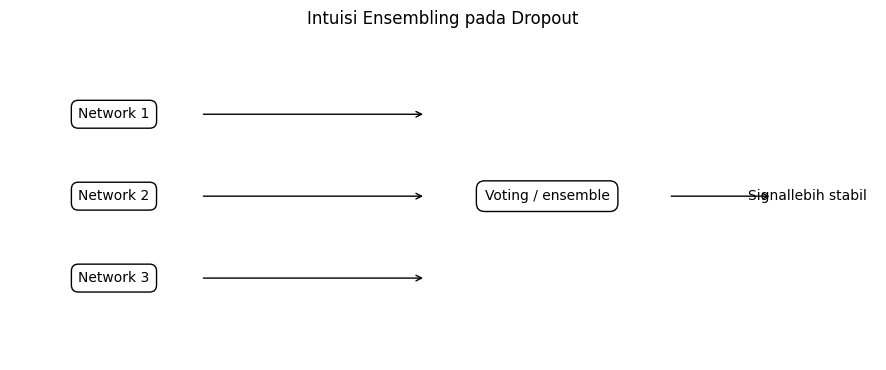

In [ ]:
fig, ax = plt.subplots(figsize=(9,3.8))
ax.axis("off")
for i,y in enumerate([0.75,0.5,0.25],1):
    ax.text(0.12,y,f"Network {i}",ha="center",va="center",bbox=dict(boxstyle="round,pad=0.5",fc="white",ec="black"))
    ax.annotate("",xy=(0.48,y),xytext=(0.22,y),arrowprops=dict(arrowstyle="->"))
ax.text(0.62,0.5,"Voting / ensemble",ha="center",va="center",bbox=dict(boxstyle="round,pad=0.6",fc="white",ec="black"))
ax.annotate("",xy=(0.88,0.5),xytext=(0.76,0.5),arrowprops=dict(arrowstyle="->"))
ax.text(0.92,0.5,"Signal\
lebih stabil",ha="center",va="center")
ax.set_title("Intuisi Ensembling pada Dropout")
plt.tight_layout(); plt.show()

## 9. Batch Gradient Descent

Pada eksperimen sebelumnya, weight diperbarui setelah satu training example. Di sini buku menggunakan **batch size = 100**, sehingga weight update dirata-ratakan dari 100 examples.

Karena output yang ingin dibandingkan adalah ukuran batch, bar chart sederhana lebih informatif.

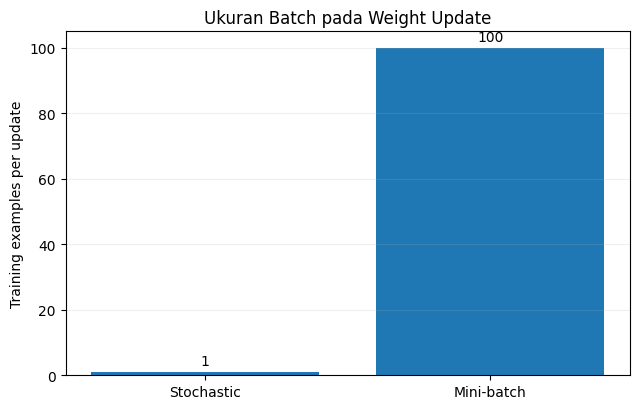

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,4.2))
methods=["Stochastic","Mini-batch"]
sizes=[1,100]
bars=ax.bar(methods,sizes)
ax.set_ylabel("Training examples per update")
ax.set_title("Ukuran Batch pada Weight Update")
for b,v in zip(bars,sizes): ax.text(b.get_x()+b.get_width()/2,v+2,str(v),ha="center")
ax.grid(axis="y",alpha=0.2); plt.tight_layout(); plt.show()

## 10. Batch Training Output

Buku menunjukkan bahwa batch training menghasilkan proses yang lebih smooth. Data berikut adalah checkpoint yang ditampilkan dalam buku.

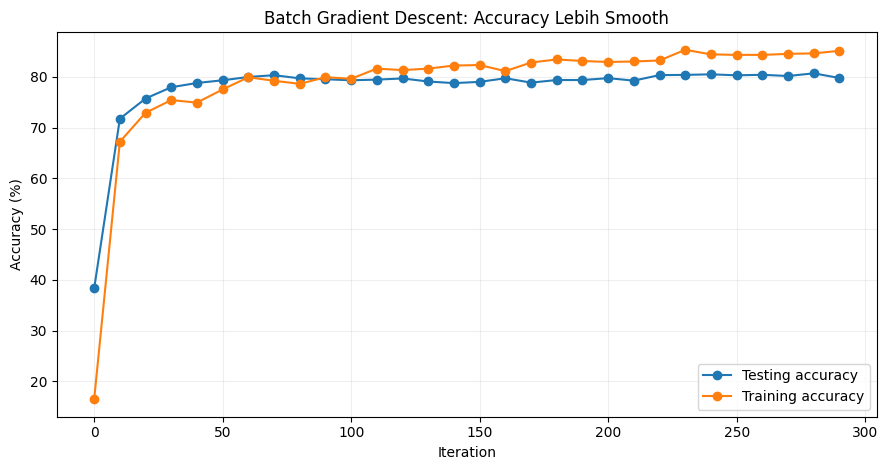

In [ ]:
iterations_batch=np.arange(0,300,10)
test_acc_batch=np.array([0.3832,0.7173,0.7571,0.7793,0.7877,0.793,0.7995,0.803,0.7968,0.795,0.793,0.7943,0.7966,0.7906,0.7874,0.7899,0.797,0.7884,0.7935,0.7935,0.7972,0.7923,0.8032,0.8036,0.8047,0.8028,0.8038,0.8014,0.8067,0.7975])
train_acc_batch=np.array([0.165,0.672,0.729,0.754,0.749,0.775,0.799,0.792,0.786,0.799,0.796,0.816,0.813,0.816,0.822,0.823,0.811,0.828,0.834,0.831,0.829,0.830,0.832,0.853,0.844,0.843,0.843,0.845,0.846,0.851])

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(iterations_batch,test_acc_batch*100,marker="o",label="Testing accuracy")
ax.plot(iterations_batch,train_acc_batch*100,marker="o",label="Training accuracy")
ax.set_title("Batch Gradient Descent: Accuracy Lebih Smooth")
ax.set_xlabel("Iteration"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 11. Comparing the Three Training Strategies

Sekarang hasil Chapter 8 dapat dibandingkan langsung. Ini adalah contoh visual yang memang **dibuat karena ada beberapa hasil eksperimen yang dapat dibandingkan**, bukan sekadar menggambar architecture.

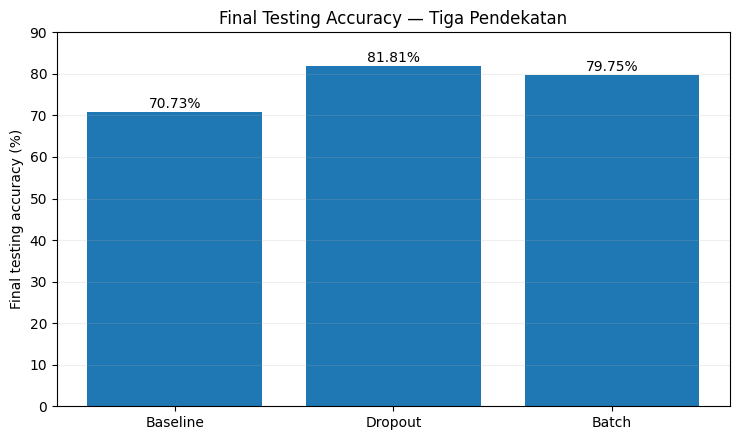

In [ ]:
comparison={
    "Baseline":70.73,
    "Dropout":81.81,
    "Batch":79.75
}
fig, ax=plt.subplots(figsize=(7.5,4.5))
bars=ax.bar(comparison.keys(),comparison.values())
ax.set_ylim(0,90); ax.set_ylabel("Final testing accuracy (%)")
ax.set_title("Final Testing Accuracy — Tiga Pendekatan")
for b,v in zip(bars,comparison.values()): ax.text(b.get_x()+b.get_width()/2,v+1,f"{v:.2f}%",ha="center")
ax.grid(axis="y",alpha=0.2); plt.tight_layout(); plt.show()

### Generalization gap

Gap dihitung sebagai **final training accuracy − final testing accuracy**. Nilai ini membantu melihat seberapa jauh model lebih baik pada data training dibanding data testing.

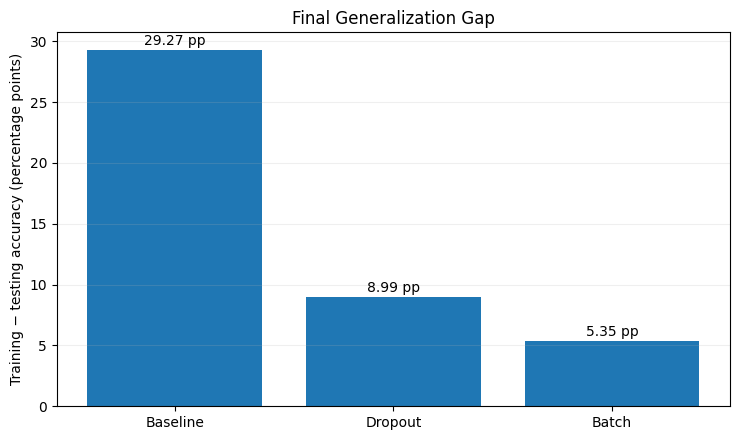

In [ ]:
gap_compare={"Baseline":100.0-70.73,"Dropout":90.8-81.81,"Batch":85.1-79.75}
fig, ax=plt.subplots(figsize=(7.5,4.5))
bars=ax.bar(gap_compare.keys(),gap_compare.values())
ax.set_ylabel("Training − testing accuracy (percentage points)")
ax.set_title("Final Generalization Gap")
for b,v in zip(bars,gap_compare.values()): ax.text(b.get_x()+b.get_width()/2,v+0.4,f"{v:.2f} pp",ha="center")
ax.grid(axis="y",alpha=0.2); plt.tight_layout(); plt.show()

## 12. Key Takeaways

1. **Overfitting** terjadi ketika network semakin baik pada training data tetapi semakin buruk pada unseen data.
2. **Test accuracy** menjadi indikator penting untuk generalization.
3. **Early stopping** menghentikan training sebelum model semakin menyesuaikan diri dengan noise.
4. **Dropout** menambahkan noise dengan mematikan hidden nodes secara acak selama training.
5. Pada contoh buku, dropout memperbaiki final testing accuracy dari sekitar **70.73% menjadi 81.81%**.
6. **Batch gradient descent** menggunakan rata-rata update dari 100 examples sehingga proses training menjadi lebih smooth dan operasi matrix dapat diproses lebih efisien.
7. Visualisasi harus mengikuti bentuk hasil: **line chart untuk training trend, bar chart untuk comparison, dan visual komposisi untuk dropout**.

## Chapter Summary

Chapter 8 memperlihatkan bahwa kemampuan network untuk meminimalkan error training tidak otomatis berarti network akan generalize dengan baik. Eksperimen MNIST memperlihatkan overfitting secara jelas: training accuracy dapat mencapai 100%, sementara testing accuracy turun menjadi sekitar 70.73%.

Buku kemudian memperkenalkan dua ide utama untuk menghadapi masalah tersebut: **regularization melalui dropout** dan **batch gradient descent** untuk membuat proses pembelajaran lebih stabil dan efisien. Hasil eksperimen menunjukkan dropout membuat network lebih sulit menghafal training data dan menghasilkan testing accuracy yang lebih baik.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Chapter 8 — Learning Signal and Ignoring Noise: Introduction to Regularization and Batching**

Sections covered:
- Three-layer network on MNIST
- Well, that was easy
- Memorization vs. generalization
- Overfitting in neural networks
- Where overfitting comes from
- The simplest regularization: Early stopping
- Industry standard regularization: Dropout
- Why dropout works: Ensembling works
- Dropout in code
- Dropout evaluated on MNIST
- Batch gradient descent
- Summary